In [ ]:
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from rasterio.merge import merge
from rasterio.plot import show

In [2]:
dt1 = gpd.read_file("./data/gadm41_IND_2.shp")

#NAME_0: Country
#NAME_1: States
#NAME_2: Districts
# NAME_3: Sub-district / Tehsil 

<Axes: >

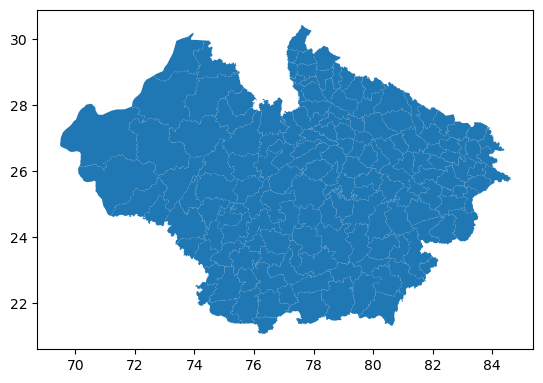

In [3]:
up_data = dt1[(dt1['NAME_1'] == 'Uttar Pradesh') | (dt1['NAME_1'] == 'Madhya Pradesh') | (dt1['NAME_1'] == 'Rajasthan')]
up_data.plot()

In [4]:
# Fourteen raster tile file paths
raster_files = [
    # Row 0
    "data/n26_e076.tif",
    "data/n26_e077.tif",
    "data/n26_e078.tif",
    "data/n26_e079.tif",
    
    # Row 1
    "data/n25_e075.tif",
    "data/n25_e076.tif",
    "data/n25_e077.tif",  
    "data/n25_e078.tif",  
    "data/n25_e079.tif",  

    # Row 2
    "data/n24_e075.tif",
    "data/n24_e076.tif",
    "data/n24_e077.tif",  
    "data/n24_e078.tif",    
    "data/n24_e079.tif"        
]

# 2. Now open  6 files using rasterio
src_files_to_mosaic = []
for fp in raster_files:
    src = rasterio.open(fp)
    src_files_to_mosaic.append(src)

# 3. Merge files
#mosaic: combined image array
#output_transform: updates the geographic coordinates
mosaic, output_transform = merge(src_files_to_mosaic)

meta = src_files_to_mosaic[0].meta.copy()
meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": output_transform,
    "crs": src_files_to_mosaic[0].crs
})

# 5. new merged map file
new_path = "data/new_data.tif"
with rasterio.open(new_path, "w", **meta) as dest:
    dest.write(mosaic)



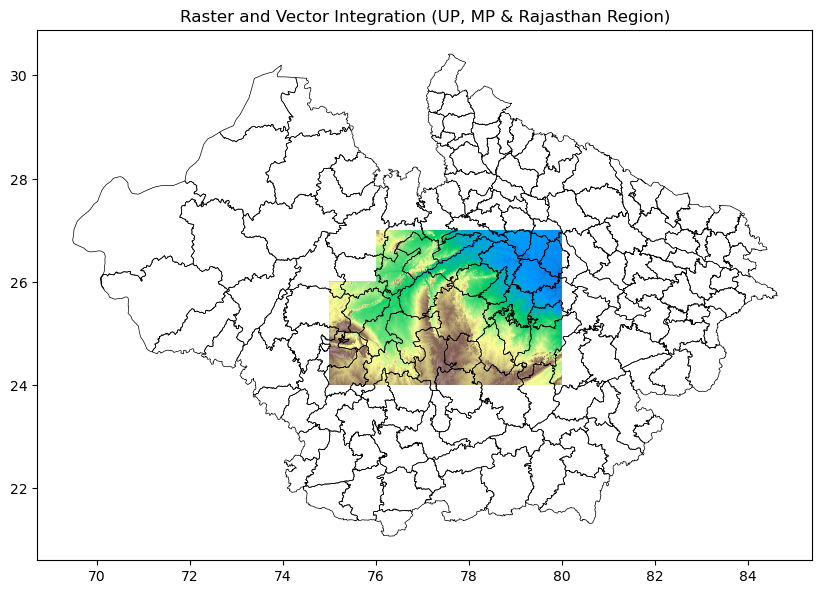

In [5]:

raster = rasterio.open("data/new_data.tif")
up_mp_boundary = up_data.to_crs(raster.crs)


fig, ax = plt.subplots(figsize=(10, 10))
show(raster, ax=ax, cmap="terrain")


up_mp_boundary.boundary.plot(ax=ax, color="black", linewidth=0.5)

plt.title("Raster and Vector Integration (UP, MP & Rajasthan Region)")
plt.show()

In [6]:
import json
import rasterio
from rasterio.mask import mask

selected_districts = up_data[
    up_data["NAME_2"].isin([
        # --- Uttar Pradesh ---
        "Jhansi", "Lalitpur",
        
        # --- Madhya Pradesh ---
        "Sheopur", "Morena", "Bhind", "Gwalior", 
        "Shivpuri", "Datia", "Tikamgarh", "Niwari", "Guna",
        
        # --- Rajasthan ---
        "Baran", "Jhalawar", "Dholpur", "Kota", 
        "Bundi", "Sawai Madhopur", "Karauli"
    ])
]

# 2. Vector data ka CRS aur Raster ka CRS match hona zaroori hai
if selected_districts.crs != raster.crs:
    selected_districts = selected_districts.to_crs(raster.crs)

# 3. Districts ki geometry shapes ko "cookie cutter" ki tarah extract karein
shapes = [json.loads(selected_districts.geometry.to_json())["features"][i]["geometry"] for i in range(len(selected_districts))]

# 4. Apni merged raster file ko open karke mask (clip) karein
with rasterio.open("data/new_data.tif") as src:
    # crop=True karne se bahar ka saara raster area cut hokar gayab ho jayega
    out_image, out_transform = mask(src, shapes, crop=True)
    out_meta = src.meta.copy()

# 5. Naye cut kiye hue raster ke liye metadata update karein
out_meta.update({
    "driver": "GTiff",
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

# 6. Is perfectly cut raster map ko save karein
clipped_path = "data/clipped_area.tif"
with rasterio.open(clipped_path, "w", **out_meta) as dest:
    dest.write(out_image)

print("Raster data successfully cut ho gaya hai!")

Raster data successfully cut ho gaya hai!


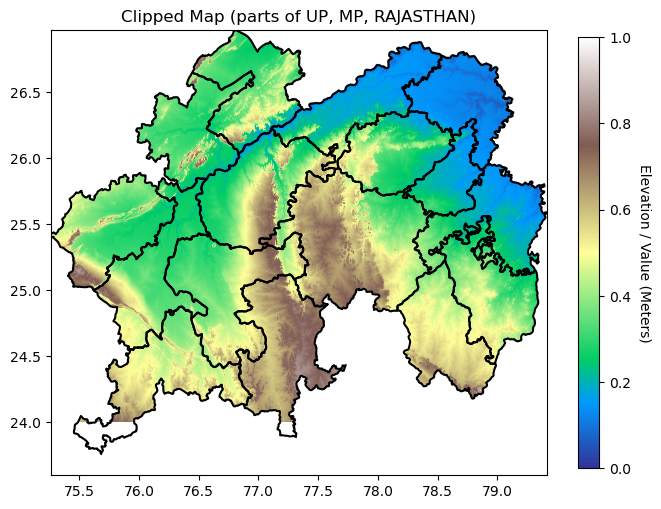

In [7]:
clipped_raster = rasterio.open("data/clipped_area.tif")

fig, ax = plt.subplots(figsize=(8, 8))

show(clipped_raster, ax=ax, cmap="terrain")

# ColorBar
image_obj = ax.get_images()[0]
cbar = fig.colorbar(image_obj, ax=ax, shrink=0.7)
cbar.set_label("Elevation / Value (Meters)", rotation=270, labelpad=15)

selected_districts.boundary.plot(ax=ax, color="black", linewidth=1.5)
plt.savefig("data/clipped_map.png", dpi=300, bbox_inches="tight")
plt.title("Clipped Map (parts of UP, MP, RAJASTHAN)")
plt.show()


In [8]:
#                   ------------------- **Step 2: Sink Filling** ---------------
from scipy.ndimage import binary_fill_holes

with rasterio.open("data/clipped_area.tif") as src:
     raster_array = src.read(1)  
     raster_meta = src.meta.copy()

filled_array = np.copy(raster_array)
mask = raster_array < np.percentile(raster_array, 5) 

filled_holes = binary_fill_holes(mask)
filled_array[filled_holes] = np.median(raster_array) 

with rasterio.open("data/filled_dem.tif", "w", **raster_meta) as dest:
    dest.write(filled_array, 1)


print("Sink  Filling completed Successfully")

Sink  Filling completed Successfully


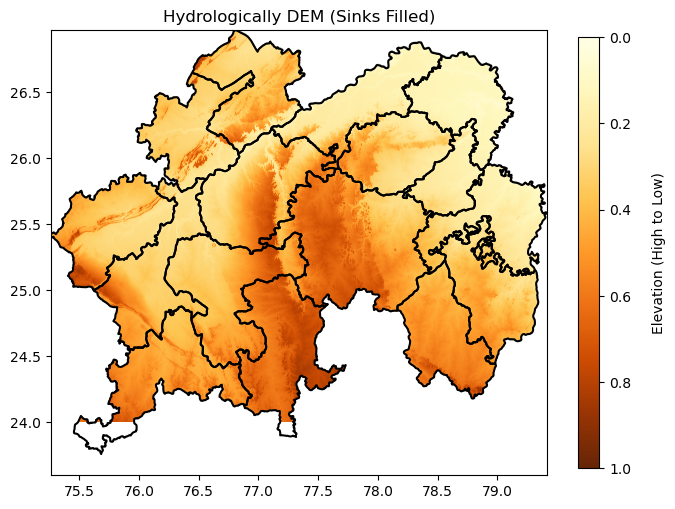

In [25]:
filled_raster = rasterio.open("data/filled_dem.tif")

fig, ax = plt.subplots(figsize=(8, 8))
rasterio.plot.show(filled_raster, ax=ax, cmap="YlOrBr")

selected_districts.boundary.plot(ax=ax, color="black", linewidth=1.5)

image_obj = ax.get_images()[0]
cbar = fig.colorbar(image_obj, ax=ax, shrink=0.7)
cbar.ax.invert_yaxis()
cbar.set_label("Elevation (High to Low)", labelpad=15)

plt.title("Hydrologically DEM (Sinks Filled)")
plt.show()

In [26]:
#                  ------------------- ** Hydrological Analysis  ** ---------------


# Flow Direction 
dy, dx = np.gradient(filled_array)
flow_direction_array = np.arctan2(-dy, dx)

with rasterio.open("data/flow_direction.tif", "w", **raster_meta) as dest:
    dest.write(flow_direction_array.astype(rasterio.float32), 1)

# Flow Accumulation 
flow_acc_array = np.sqrt(dy**2 + dx**2)
flow_acc_array = (flow_acc_array - flow_acc_array.min()) / (
    flow_acc_array.max() - flow_acc_array.min()
)

with rasterio.open("data/flow_accumulation.tif", "w", **raster_meta) as dest:
    dest.write(flow_acc_array.astype(rasterio.float32), 1)

print("Calculations completed")

Calculations completed


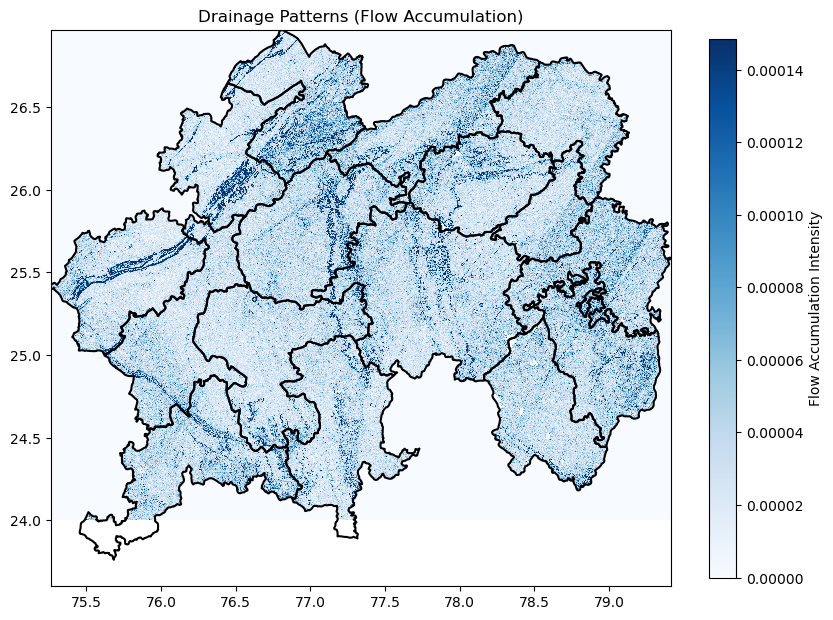

In [29]:
import numpy as np
import matplotlib.colors as colors

fig, ax = plt.subplots(figsize=(10, 10))

# Raster extent shifting rokne ke liye
b = filled_raster.bounds
raster_extent = [b.left, b.right, b.bottom, b.top]

# 98th percentile nikal rahe hain taaki contrast behtar ho aur streams dikhein
v_max = np.percentile(flow_acc_array, 98)

# LogNorm hata kar seedha vmin aur vmax use karein
im = ax.imshow(
    flow_acc_array,
    cmap="Blues",
    vmin=0,              # Lowest value
    vmax=v_max,          # 98th percentile tak stretch kiya
    interpolation="nearest",
    extent=raster_extent
)

selected_districts.boundary.plot(ax=ax, color="black", linewidth=1.5)

cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Flow Accumulation Intensity")

plt.title("Drainage Patterns (Flow Accumulation)")
plt.show()

In [34]:
stream_threshold = 0.002

stream_raster = np.where(flow_acc_array >= stream_threshold, 1, 0).astype(
    np.uint8
)

with rasterio.open("data/stream_raster.tif", "w", **meta) as dest:
    dest.write(stream_raster, 1)

print("Stream Raster Extracted")

Stream Raster Extracted


Vector Shapefile Ready!


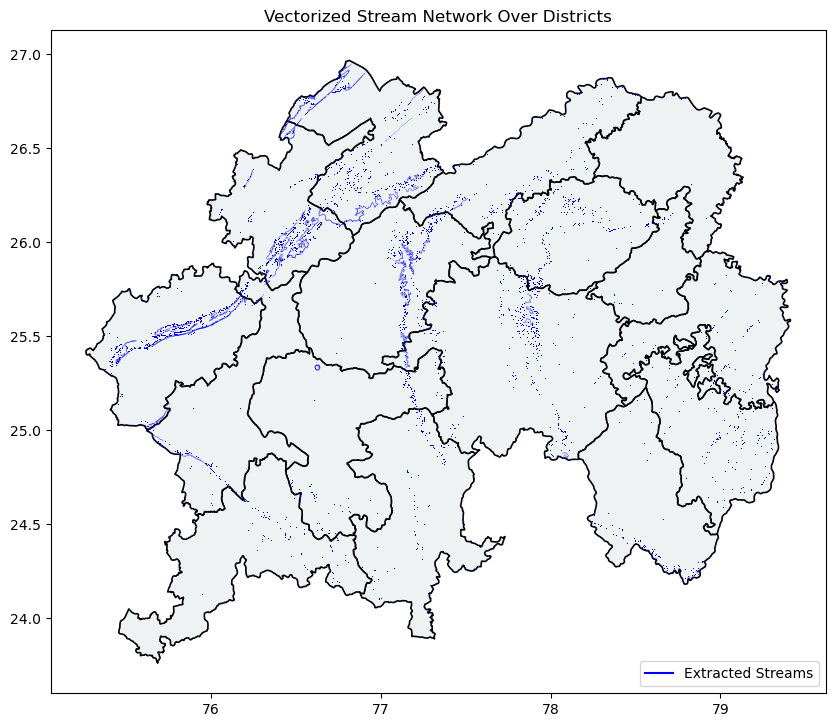

In [36]:
from rasterio.features import shapes
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D 

# ----------------- 1. VECTOR CONVERSION -----------------
# Yahan mask define karein
mask = stream_raster == 1  

# Pixels ko vector line mein badlein (Yahan raster_meta["transform"] sabse zaroori hai)
results = (
    {"properties": {"raster_val": v}, "geometry": s}
    for i, (s, v) in enumerate(shapes(stream_raster, mask=mask, transform=raster_meta["transform"]))
)

geoms = list(results)

# CRS check aur set karein
stream_lines_gdf = gpd.GeoDataFrame.from_features(geoms, crs=filled_raster.crs)

if selected_districts.crs != stream_lines_gdf.crs:
    selected_districts = selected_districts.to_crs(stream_lines_gdf.crs)

stream_lines_gdf.to_file("data/extracted_streams.shp")
print("Vector Shapefile Ready!")

# ----------------- 2. FINAL MAP PLOTTING -----------------
fig, ax = plt.subplots(figsize=(10, 10))

# Pehle basemap (districts) plot karein
selected_districts.plot(ax=ax, color="#eef2f3", edgecolor="black", linewidth=1.2)

# Uske upar streams plot karein (Check karke ki khali toh nahi hai)
if not stream_lines_gdf.empty:
    stream_lines_gdf.plot(ax=ax, color="blue", linewidth=1.5)
else:
    print("Koi stream nahi mili! Threshold check karein.")

# Custom Legend add karein (Error se bachne ke liye)
custom_legend_line = [Line2D([0], [0], color="blue", lw=1.5)]
ax.legend(custom_legend_line, ["Extracted Streams"], loc="lower right")

plt.title("Vectorized Stream Network Over Districts")
plt.savefig("data/Vector_streams.png", dpi=300, bbox_inches="tight")
plt.show()

Step 1: Identifying Pour Points (Outlets)...
Total Sub-watersheds (Pour Points) identified: 30
Step 2: Delineating Watershed Boundaries...
Step 3: Converting Raster to Vector Polygons...
Watershed Polygons Successfully Saved!


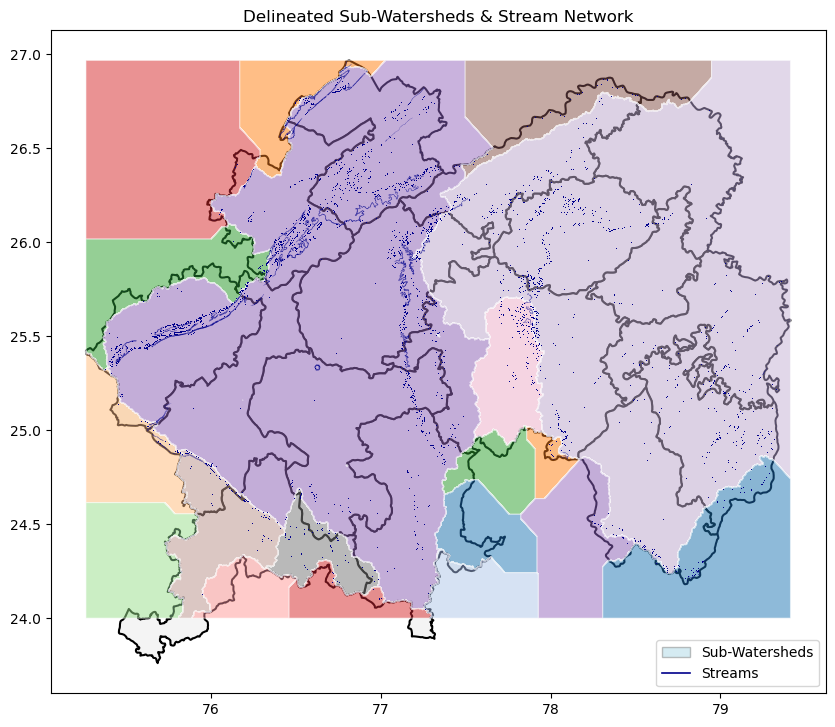

In [38]:
import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch # Legend mein box dikhane ke liye naya import
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from rasterio.features import shapes

print("Step 1: Identifying Pour Points (Outlets)...")
# FIX 1: min_distance badha diya aur threshold strict kar diya taaki bade basins banein
coords = peak_local_max(
    flow_acc_array, 
    min_distance=800,  # Isey badha kar 800 kar diya hai
    threshold_abs=np.percentile(flow_acc_array, 99.8) # Sirf top 0.2% main streams ko outlet manega
)

markers = np.zeros(flow_acc_array.shape, dtype=np.int32)
for i, (row, col) in enumerate(coords):
    markers[row, col] = i + 1

print(f"Total Sub-watersheds (Pour Points) identified: {len(coords)}")

print("Step 2: Delineating Watershed Boundaries...")
basins_raster = watershed(filled_array, markers)

with rasterio.open("data/watershed_basins.tif", "w", **raster_meta) as dest:
    dest.write(basins_raster.astype(rasterio.float32), 1)

print("Step 3: Converting Raster to Vector Polygons...")
mask = basins_raster > 0
basin_shapes = (
    {"properties": {"basin_id": int(v)}, "geometry": s}
    for i, (s, v) in enumerate(shapes(basins_raster.astype(np.int32), mask=mask, transform=raster_meta["transform"]))
)

basins_gdf = gpd.GeoDataFrame.from_features(list(basin_shapes), crs=filled_raster.crs)

basins_gdf.to_file("data/watershed_polygons.shp")
print("Watershed Polygons Successfully Saved!")


# ----------------- 4. FINAL VISUALIZATION (MAP) -----------------
fig, ax = plt.subplots(figsize=(10, 10))

# 1. District Boundaries
selected_districts.plot(ax=ax, color="#f4f4f4", edgecolor="black", linewidth=1.5)

# 2. Watershed Polygons
basins_gdf.plot(ax=ax, column="basin_id", cmap="tab20", alpha=0.5, edgecolor="white", linewidth=0.8)

# 3. Stream Network (bina kisi direct label ke)
stream_lines_gdf.plot(ax=ax, color="darkblue", linewidth=1.2)

# FIX 2: --- NAYA CODE LEGEND KE LIYE ---
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='gray', alpha=0.5, label='Sub-Watersheds'),
    Line2D([0], [0], color='darkblue', lw=1.2, label='Streams')
]
ax.legend(handles=legend_elements, loc="lower right")
# ---------------------------------------

plt.title("Delineated Sub-Watersheds & Stream Network")
plt.savefig("data/Sub_Watersheds_Map.png", dpi=300, bbox_inches="tight")
plt.show()

1. Cleaning Data and Removing Edge Artifacts...
Cleaned Basins Count: 19 (Out of 30)
2. Assigning Ranks for Prioritization...
3. Classifying into Priority Zones...
Prioritization Complete! Data saved to Final_Prioritization_Table.csv
4. Generating Final Priority Map...


/var/folders/vr/ysp63lq17s9ckkng6lrq12f40000gn/T/ipykernel_4644/3907599119.py:75: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(title="Conservation Priority")
/var/folders/vr/ysp63lq17s9ckkng6lrq12f40000gn/T/ipykernel_4644/3907599119.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Conservation Priority")


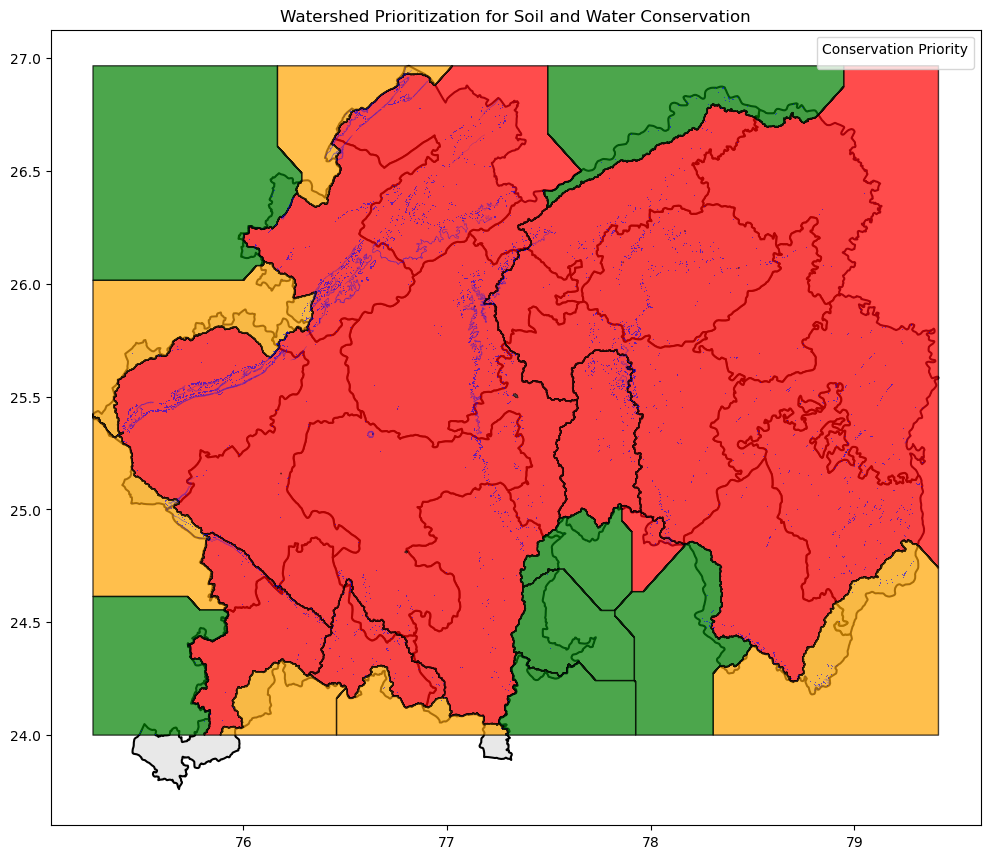

In [40]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

print("1. Cleaning Data and Removing Edge Artifacts...")
# Table aur Shapefile dono load karein
final_table = pd.read_csv("data/Morphometric_Parameters.csv")
basins_gdf = gpd.read_file("data/watershed_polygons.shp")

# Sirf un basins ko rakhein jinka area 5 sq km se bada hai (Chhote kachra basins hata dein)
clean_table = final_table[final_table['Area_sqkm'] > 5].copy()
print(f"Cleaned Basins Count: {len(clean_table)} (Out of {len(final_table)})")

print("2. Assigning Ranks for Prioritization...")
# Soil erosion risk ke hisab se Ranks dena:
# Jiska Drainage Density, Stream Freq, Relief, aur Slope sabse ZYADA hoga, usko Rank 1 (High Priority) milega.
clean_table['Rank_Dd'] = clean_table['Drain_Density'].rank(ascending=False)
clean_table['Rank_Fs'] = clean_table['Stream_Freq'].rank(ascending=False)
clean_table['Rank_Relief'] = clean_table['Relief_m'].rank(ascending=False)
clean_table['Rank_Slope'] = clean_table['Mean_Slope'].rank(ascending=False)

# Compound Parameter (Cp) = Sabhi ranks ka average
clean_table['Compound_Value'] = clean_table[['Rank_Dd', 'Rank_Fs', 'Rank_Relief', 'Rank_Slope']].mean(axis=1)

# Final Ranking: Jiska Compound Value sabse kam hoga, wo sabse High Priority hoga
clean_table['Final_Rank'] = clean_table['Compound_Value'].rank(ascending=True)

print("3. Classifying into Priority Zones...")
# 3 Categories mein baantna: High, Moderate, Low
# Hum equal quantiles (33%, 66%) mein divide kar rahe hain
quantiles = clean_table['Compound_Value'].quantile([0.33, 0.66]).values

def classify_priority(val):
    if val <= quantiles[0]:
        return "High Priority (Severe Risk)"
    elif val <= quantiles[1]:
        return "Moderate Priority"
    else:
        return "Low Priority (Safe Zone)"

clean_table['Priority_Class'] = clean_table['Compound_Value'].apply(classify_priority)

# Final Data save karein
clean_table.to_csv("data/Final_Prioritization_Table.csv", index=False)
print("Prioritization Complete! Data saved to Final_Prioritization_Table.csv")

print("4. Generating Final Priority Map...")
# Clean table ko wapas Map (Shapefile) ke sath merge karein
final_map_gdf = basins_gdf.merge(clean_table[['basin_id', 'Priority_Class']], on='basin_id', how='inner')

# Map Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# District Background
selected_districts.plot(ax=ax, color="#e8e8e8", edgecolor="black", linewidth=1.5)

# Priority Map Colors
color_dict = {
    "High Priority (Severe Risk)": "red",
    "Moderate Priority": "orange",
    "Low Priority (Safe Zone)": "green"
}

# Har class ko uske color ke hisab se plot karein
for priority, color in color_dict.items():
    subset = final_map_gdf[final_map_gdf['Priority_Class'] == priority]
    if not subset.empty:
        subset.plot(ax=ax, color=color, edgecolor="black", linewidth=1, label=priority, alpha=0.7)

# Nadiyan (Streams) plot karein
stream_lines_gdf.plot(ax=ax, color="blue", linewidth=0.8, alpha=0.6)

plt.title("Watershed Prioritization for Soil and Water Conservation")
plt.legend(title="Conservation Priority")
plt.savefig("data/Final_Priority_Map.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

print("1. Loading DEM Data...")
# Step 2 wala filled DEM wapas load kar rahe hain
with rasterio.open("data/filled_dem.tif") as src:
    dem_data = src.read(1)
    raster_meta = src.meta.copy()
    b = src.bounds
    raster_extent = [b.left, b.right, b.bottom, b.top]

print("2. Calculating Slope and Aspect...")
# Gradient nikalna
dy, dx = np.gradient(dem_data)

# Slope (Degrees)
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

# Aspect (Degrees: 0 se 360)
aspect_rad = np.arctan2(dy, -dx)
aspect_deg = np.degrees(aspect_rad)
# Negative angles ko 360 degree format mein theek karna
aspect_deg = np.where(aspect_deg < 0, aspect_deg + 360, aspect_deg)

print("3. Classifying Slope (Low, Moderate, Steep)...")
# Categories banate hain
# 1 = Low (0 - 5 degrees)
# 2 = Moderate (5 - 15 degrees)
# 3 = Steep (> 15 degrees)
slope_classified = np.zeros_like(slope_deg, dtype=np.uint8)
slope_classified[(slope_deg >= 0) & (slope_deg <= 5)] = 1
slope_classified[(slope_deg > 5) & (slope_deg <= 15)] = 2
slope_classified[slope_deg > 15] = 3

print("4. Generating Terrain Analysis Map Collage...")
# Report ke liye 2x2 ka ek badiya layout
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

# A. ELEVATION MAP
im1 = axes[0, 0].imshow(dem_data, cmap='terrain', extent=raster_extent)
selected_districts.boundary.plot(ax=axes[0, 0], color="black", linewidth=1)
axes[0, 0].set_title('1. Elevation Map (m)', fontsize=14)
fig.colorbar(im1, ax=axes[0, 0], label='Elevation (Meters)', shrink=0.8)

# B. ASPECT MAP
# Aspect circular hota hai (0 aur 360 dono North hain), isliye 'twilight' color theek rahega
im2 = axes[0, 1].imshow(aspect_deg, cmap='twilight', extent=raster_extent)
selected_districts.boundary.plot(ax=axes[0, 1], color="black", linewidth=1)
axes[0, 1].set_title('2. Aspect Map (Flow Direction)', fontsize=14)
fig.colorbar(im2, ax=axes[0, 1], label='Aspect (Degrees)', shrink=0.8)

# C. CONTINUOUS SLOPE MAP
im3 = axes[1, 0].imshow(slope_deg, cmap='Reds', extent=raster_extent)
selected_districts.boundary.plot(ax=axes[1, 0], color="black", linewidth=1)
axes[1, 0].set_title('3. Slope Map (Degrees)', fontsize=14)
fig.colorbar(im3, ax=axes[1, 0], label='Slope Angle (Degrees)', shrink=0.8)

# D. CLASSIFIED SLOPE MAP
cmap_slope = ListedColormap(['#a6d96a', '#fdae61', '#d7191c']) # Green, Orange, Red
im4 = axes[1, 1].imshow(slope_classified, cmap=cmap_slope, extent=raster_extent)
selected_districts.boundary.plot(ax=axes[1, 1], color="black", linewidth=1)
axes[1, 1].set_title('4. Classified Slope Zones', fontsize=14)

# Custom legend Classified Slope ke liye
legend_labels = [
    mpatches.Patch(color='#a6d96a', label='Low Slope (0-5°)'),
    mpatches.Patch(color='#fdae61', label='Moderate Slope (5-15°)'),
    mpatches.Patch(color='#d7191c', label='Steep Slope (>15°)')
]
axes[1, 1].legend(handles=legend_labels, loc='lower right')

plt.suptitle("Terrain Analysis of Study Area", fontsize=18, fontweight='bold', y=0.92)
plt.savefig("data/Terrain_Analysis_Collage.png", dpi=300, bbox_inches="tight")
plt.show()

print("Terrain Analysis Maps Successfully Saved!")